In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data, regions, popls
from sklearn.impute import KNNImputer, SimpleImputer

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
# regions = sorted(df['region'].unique())
# popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

In [316]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report

ordinal_encoder = OrdinalEncoder()
Xcat = ordinal_encoder.fit_transform(df[genes].values.astype('<U2'))

one_hot_encoder = OneHotEncoder(sparse=False)
Xoh = one_hot_encoder.fit_transform(df[genes].values.astype('<U2'))
grps_xoh = df[genes].nunique().values

Xnum = df_chs.loc[:, df_chs.nunique(dropna=False) > 1].values
grps_xnum = np.sum( (df_chs.nunique(dropna=False) > 1).values.reshape(-1, 4) , axis=-1)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])

def cv_splitter(X, y, strat, n_splits, shuffle=True, random_state=None):
    for train_idxs, test_idxs in StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state).split(X, strat):
        yield X[train_idxs], X[test_idxs], y[train_idxs], y[test_idxs]

def group_sum(arr, grp_sizes):
    assert arr.shape[-1] == np.sum(grp_sizes)
    result = []
    lb = 0
    for grp_size in grp_sizes:
        result.append( np.sum(arr[..., lb:lb+grp_size], axis=-1) )
        lb += grp_size
    result = np.stack(result, axis=-1)
    return result

In [219]:
from sklearn.inspection import permutation_importance


## Distance-irrelevant classifiers: CategoricalNB, Categorical RF, Catboost

In [335]:
from sklearn.naive_bayes import CategoricalNB

fi_cat_nb_var = []
fi_cat_nb_perm = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xcat, y, df['popl'], n_splits=5, random_state=42):
    model = CategoricalNB(
        alpha=1,
        min_categories=np.max(Xcat, axis=0).astype(int)+1
        )
    model.fit(X_train, y_train)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
        )
    fi_cat_nb_var.append( np.array([np.sum(np.var(np.exp( log_prob ), axis=0)) for log_prob in model.feature_log_prob_]) )
    fi_cat_nb_perm.append( permutation_importance(model, X_test, y_test, scoring='neg_log_loss', n_repeats=30, random_state=42)['importances_mean'] )

train	test
91.74%	86.73%
91.50%	89.32%
91.34%	89.00%
90.53%	91.26%
91.18%	89.94%


In [269]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {'n_estimators': 568,
'criterion': 'entropy',
'max_depth': 14,
'min_samples_split': 0.003294411356704213,
'min_samples_leaf': 0.0010234416524205442,
'random_state': 42}

fi_cat_rf_in = []
fi_cat_rf_perm = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xoh, y, df['popl'], n_splits=5, random_state=42):
    model = RandomForestClassifier(
        **rf_params
        )
    model.fit(X_train, y_train)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
        )
    fi_cat_rf_in.append( group_sum(model.feature_importances_, grps_xoh) )
    fi_cat_rf_perm.append( group_sum(
        permutation_importance(model, X_train, y_train, scoring='accuracy', n_repeats=30, random_state=42)['importances_mean'],
        grps_xoh
    )  )

train	test
100.00%	84.47%
100.00%	88.67%
100.00%	86.73%
99.92%	89.64%
99.92%	86.69%


In [272]:
from catboost import CatBoostClassifier, Pool

print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(df[genes].values.astype('<U2'), y, df['popl'], n_splits=5, random_state=42):
    model = CatBoostClassifier()
    model.fit(
        Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes),
        verbose=0
    )
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train).ravel() == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test).ravel() == y_test)), sep=''
    )
    break

train	test
97.81%	88.67%


In [298]:
from catboost import EFstrType

fi_catboost_loss = model.get_feature_importance(
    Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes), 
    type=EFstrType.LossFunctionChange
)
fi_catboost_val = model.get_feature_importance(
    Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes), 
    type=EFstrType.PredictionValuesChange
)

SpearmanrResult(correlation=0.8367742611963648, pvalue=1.7150344283801368e-44)


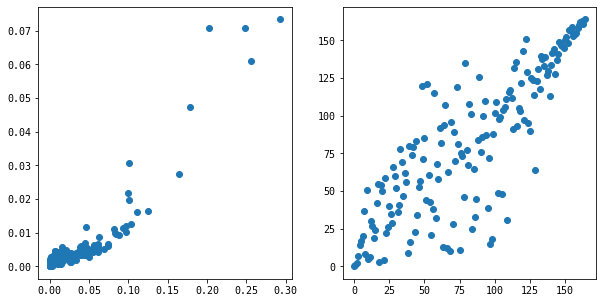

In [133]:
from scipy.stats import spearmanr
print(spearmanr(cat_nb_fi, fi_in))
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
ax = axs[0]
ax.scatter(cat_nb_fi, fi_in)
ax = axs[1]
ax.scatter(np.argsort(np.argsort(cat_nb_fi)), np.argsort(np.argsort(fi_in)))
plt.show(); plt.close()

SpearmanrResult(correlation=0.8403646784688371, pvalue=3.2681645864873725e-45)


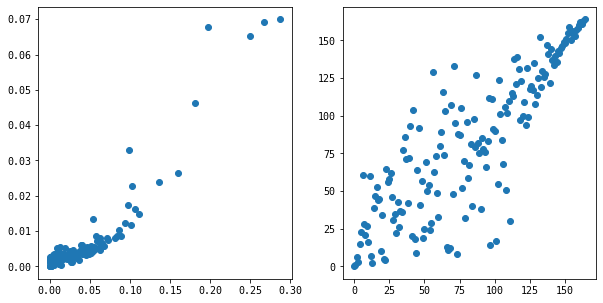

In [170]:
from scipy.stats import spearmanr
print(spearmanr(cat_nb_fi, fi_in))
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
ax = axs[0]
ax.scatter(cat_nb_fi, fi_in)
ax = axs[1]
ax.scatter(np.argsort(np.argsort(cat_nb_fi)), np.argsort(np.argsort(fi_in)))
plt.show(); plt.close()

## LR, SVM, KNN, MultinomialNB

In [191]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics.pairwise import distance_metrics

def nan_l1_dist(X, Y, missing_values=np.nan):
    # if Y is None:
    #     Y = X
    # assert np.isnan(missing_values)

    diff = X - Y
    na_count = np.sum(np.isnan(diff))
    distance = np.nansum(np.abs(diff))
    distance *= (X.shape[-1] / (X.shape[-1]-na_count))
    return distance

    # X_fill = np.nan_to_num(X)
    # Y_fill = np.nan_to_num(Y)
    # distances = distance_metrics()['manhattan'](X_fill, Y_fill)
    # distances -= np.dot(np.abs(X_fill), np.isnan(Y).T)
    # distances -= np.dot(np.isnan(X), np.abs(Y_fill).T)
    
    # notna_count = np.dot(~np.isnan(X), ~np.isnan(Y).T)
    # distances[notna_count == 0] = np.nan
    # distances /= np.maximum(1, notna_count)
    # distances *= X.shape[-1]

    # return distances    

In [303]:
from sklearn.linear_model import LogisticRegression

lr_params = {
    'knnimputer__n_neighbors': 45,
    'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}

print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        LogisticRegression(
            penalty='l2',
            C=1., 
            solver='saga', 
            max_iter=1000,
            random_state=42
        )
    )
    model.set_params(**lr_params)
    model.fit(X_train, y_train)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
90.93%	88.35%
91.66%	86.73%
91.42%	87.38%
90.93%	89.32%
91.50%	87.66%


In [305]:
fi_lr_in = model[-1].coef_

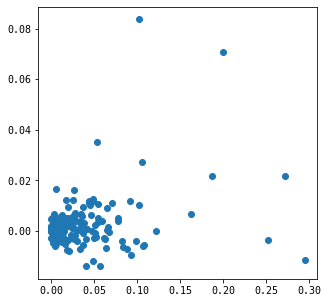

In [336]:
fi_1 = fi_cat_nb_var[2]
fi_2 = fi_cat_nb_perm[2]
# fi_2 = group_sum( np.linalg.norm(fi_lr_in, ord=2, axis=0) , grps_xnum)
rearrange = lambda x: x
# rearrange = lambda x: np.argsort(np.argsort(x))
plt.figure(figsize=(5, 5))
plt.scatter(rearrange(fi_1), rearrange(fi_2))

In [206]:
from sklearn.svm import SVC

print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        SVC(
            C=1., 
            kernel='rbf',
            degree=3,
            gamma='scale',
            coef0=0.0,
            random_state=42
        )
    )
    model.fit(X_train, y_train)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
94.57%	90.29%
94.33%	87.06%
93.52%	89.00%
93.44%	92.23%
94.26%	87.01%


In [193]:
from sklearn.neighbors import KNeighborsClassifier

print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        KNeighborsClassifier(
            n_neighbors=25, 
            weights='uniform',
            metric='manhattan'
        )
    )
    model.fit(X_train, y_train)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, a

82.91%	79.61%


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, a

83.32%	81.55%


...

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, a

83.72%	82.52%


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


83.01%	80.84%


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [208]:
from sklearn.naive_bayes import MultinomialNB

print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MultinomialNB(
            alpha=1.
        )
    )
    model.fit(X_train, y_train)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
90.93%	86.41%
90.69%	88.03%
90.69%	89.64%
89.31%	92.23%
90.21%	90.26%


In [6]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.7149797570850203
0.7119741100323624


In [7]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.9101214574898785
0.8576051779935275


In [9]:
from sklearn.naive_bayes import ComplementNB

model = ComplementNB()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.6890688259109312
0.6925566343042071


## Trees

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.8122977346278317


In [11]:
from sklearn.tree import ExtraTreeClassifier

model = ExtraTreeClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.6699029126213593


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.8414239482200647


In [13]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.86084142394822


In [16]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier()
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

1.0
0.8576051779935275


In [ ]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Categorical, Integer, Continuous
from sklearn.model_selection import StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(Xnum, y, test_size=0.2, stratify=y, random_state=42)

ga_cv = GASearchCV(
    estimator=make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        LogisticRegression(
            penalty='l2',
            C=1., 
            max_iter=10000,
            solver='saga',
            l1_ratio=0.5,
            random_state=42
        )
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='accuracy', 
    param_grid={
        'knnimputer__n_neighbors': Integer(2, 50),
        'knnimputer__metric': Categorical(['nan_euclidean', nan_l1_dist]),

        'logisticregression__penalty': Categorical(['l1', 'l2', 'elasticnet']), 
        'logisticregression__C': Continuous(1e-2, 1e2, distribution='log-uniform'),
        'logisticregression__l1_ratio': Continuous(0.01, 0.99, distribution='uniform')
    },
    verbose=True
)
ga_cv.fit(X_train, y_train)
# ga_cv.best_params_ = {'knnimputer__n_neighbors': 45,
#  'knnimputer__metric': <function __main__.nan_l1_dist(X, Y, missing_values=nan)>,
#  'logisticregression__penalty': 'elasticnet',
#  'logisticregression__C': 0.029598512368422047,
#  'logisticregression__l1_ratio': 0.23215770943111214}